In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Logistic / Sigmoid function

$$ y = \frac{1}{1+e^{-z}} $$

In [2]:
def sigmoid(z):
    y = 1/(1 + np.exp(-z))
    return y

In [3]:
sigmoid(0).item()

0.5

In [4]:
sigmoid(10).item()

0.9999546021312976

In [5]:
sigmoid(-5).item()

0.0066928509242848554

### Plot of sigmoid functon

In [6]:
z = np.linspace(-5,5,100)
y = sigmoid(z)

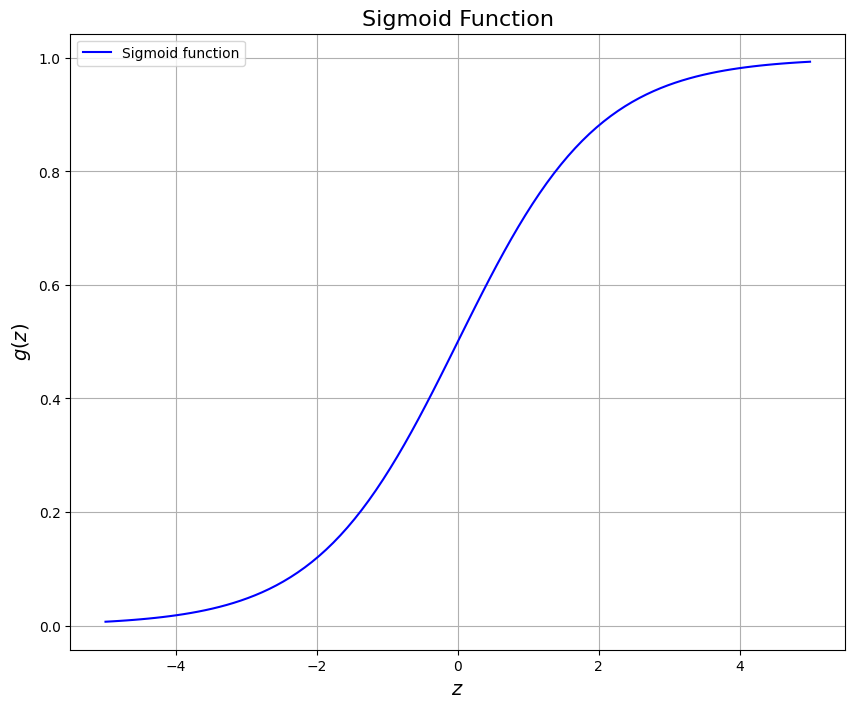

In [7]:
plt.figure(figsize=(10,8))
plt.plot(z, y, 'b-', label="Sigmoid function")
plt.grid()
plt.title("Sigmoid Function", fontsize=16)
plt.xlabel("$z$", fontsize=14)
plt.ylabel("$g(z)$", fontsize=14)
plt.legend()
plt.show()

## Derivative of logistic / sigmoid function

if $g(z) = \frac{1}{1+e^{-z}} $

then $ g'(z) = \frac{dg(z)}{dz} = g(z)(1- g(z)) $

In [8]:
def derivative_of_sigmoid(z):
    g = sigmoid(z)
    return g*(1-g)

In [9]:
d = derivative_of_sigmoid(z)

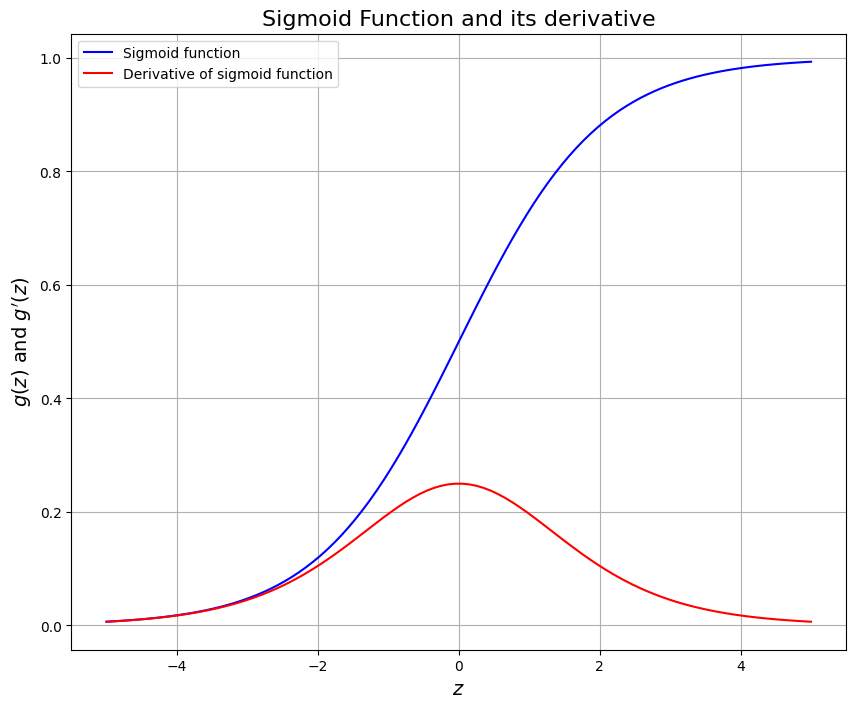

In [10]:
plt.figure(figsize=(10,8))
plt.plot(z, y, 'b-', label="Sigmoid function")
plt.plot(z, d, 'r-', label="Derivative of sigmoid function")
plt.grid()
plt.title("Sigmoid Function and its derivative", fontsize=16)
plt.xlabel("$z$", fontsize=14)
plt.ylabel("$g(z)$ and $g'(z)$", fontsize=14)
plt.legend()
plt.show()

## Cost function

First we shall create a classification dataset and based on that we shall observe the performance of cost functions

In [12]:
from sklearn.datasets import make_classification
import pandas as pd

In [13]:
X, y = make_classification(n_samples=500,          # number of data points in the dataset
                           n_features=2,            # number of features / independent variables
                           n_classes=2,             # number of classes in the dataset
                           n_clusters_per_class=1,  # number of cluster in each class
                           n_informative=2,         # number of informative features
                           n_redundant=0,           # number of redundant features
                           n_repeated=0,            # number of repeated features
                           class_sep=3,             # Larger values spread out the clusters/classes.
                           shuffle=True)            # whether to shuffle the dataset

In [14]:
dataset = pd.DataFrame(np.hstack((X, y.reshape(-1,1))), columns=['x1', 'x2', 'target'])

In [15]:
dataset.head(10)

,x1,x2,target
0,4.197443,-2.852957,1.0
1,-2.830867,-1.523696,0.0
2,-2.327465,-2.701743,0.0
3,3.248957,-2.994647,1.0
4,-2.902762,-2.831029,0.0
5,-3.079398,-4.411606,0.0
6,-3.503366,-3.483850,0.0
7,2.567173,-3.032916,1.0
8,3.167885,-3.006298,1.0
9,3.843232,-2.893070,1.0


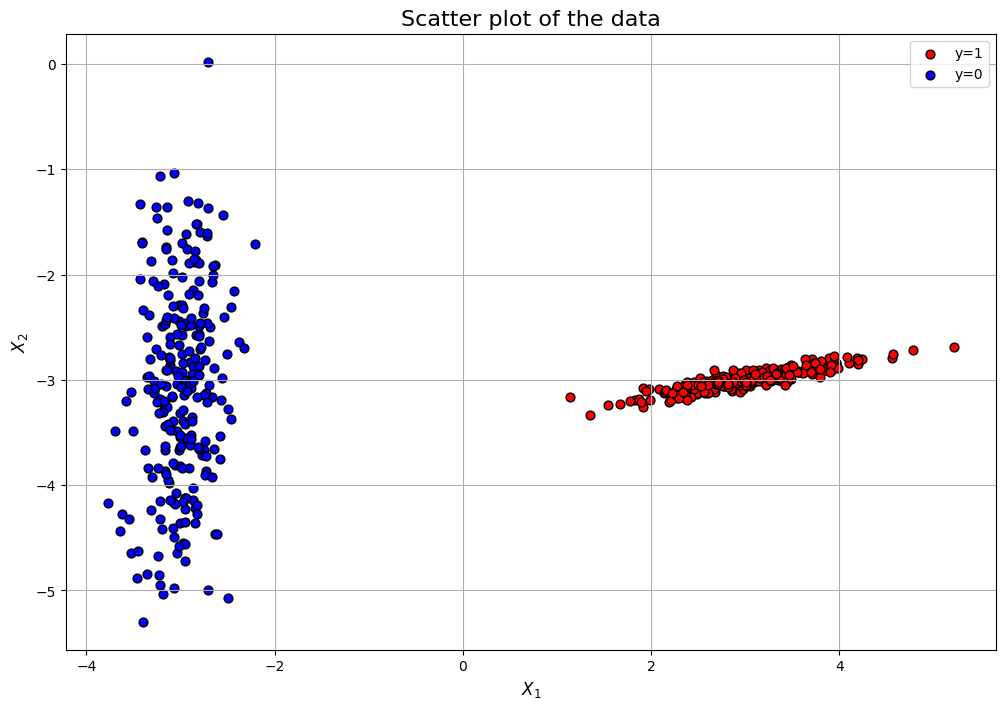

In [16]:
plt.figure(figsize=(12,8))
data_1 = dataset[dataset['target']==1]
data_0 = dataset[dataset['target']==0]
plt.scatter(x=data_1['x1'].values, y=data_1['x2'].values, s=40, c='r', edgecolor='k', label="y=1")
plt.scatter(x=data_0['x1'].values, y=data_0['x2'].values, s=40, c='b', edgecolor='k', label="y=0")
plt.title("Scatter plot of the data",fontsize=16)
plt.xlabel("$X_1$", fontsize=12)
plt.ylabel("$X_2$", fontsize=12)
plt.grid()
plt.legend()
plt.show()

### Why not to use mean squared error cost function in classification?

In [17]:
def mse_cost(y_pred, y_actual):
    return 0.5*np.mean(np.square(np.array(y_pred) - np.array(y_actual)))

The hypostheis function will look like:

$$ y_p = h_{\theta}(x) = g\left(\theta_0 + \sum_{j=1}^{k}\theta_k x_k \right) = g(\theta_0 + \theta_1 x_1 + \theta_2 x_2) $$

Where $g(z) = \frac{1}{1+e^{-z}}$

*Suppose*

$\theta_1 = \theta_2 = 1$

and $\theta_0$ is variable between -10 to +10

In [18]:
X = np.hstack((np.ones((len(X), 1)), X))

In [19]:
X

array([[ 1.        ,  4.19744316, -2.85295743],
       [ 1.        , -2.83086733, -1.52369601],
       [ 1.        , -2.3274646 , -2.70174311],
       ...,
       [ 1.        , -3.14092616, -2.40498443],
       [ 1.        ,  3.89788639, -2.92724329],
       [ 1.        ,  2.81295041, -3.03486919]], shape=(500, 3))

In [20]:
theta_0_values = np.linspace(-10, 10, 100)

In [21]:
theta_1 = 1
theta_2 = 1

In [22]:
# one example 

theta = np.array([-2,1,1]).reshape(-1,1)

theta

array([[-2],
       [ 1],
       [ 1]])

In [23]:
mse_costs = []

for i in range(len(theta_0_values)):
    theta_0 = theta_0_values[i]
    theta = np.array([theta_0, theta_1, theta_2]).reshape(-1,1)
    z_p = X @ theta
    y_p = sigmoid(z_p)
    cost = mse_cost(y_p, y)
    mse_costs.append(cost)

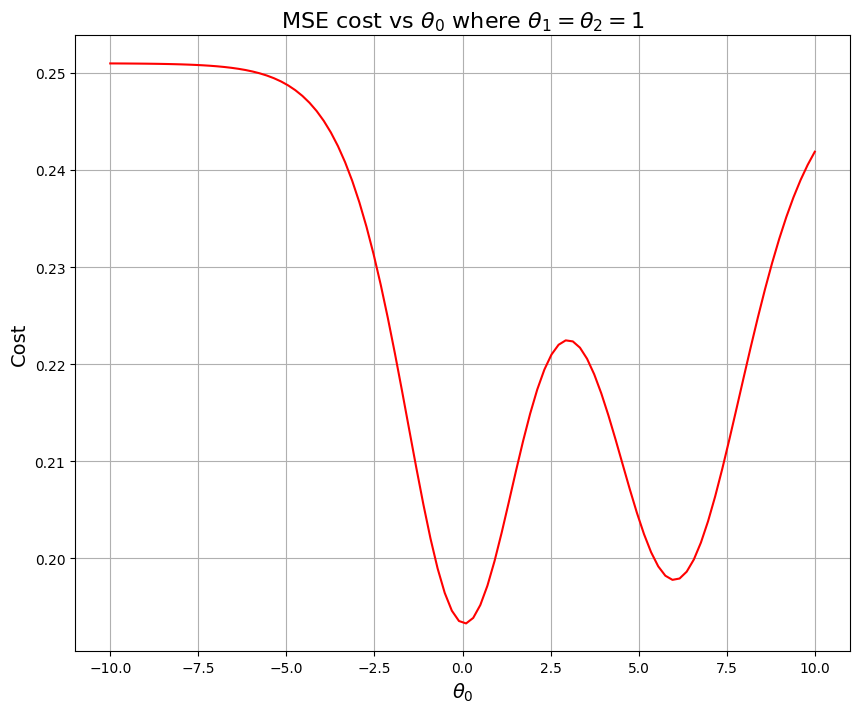

In [24]:
plt.figure(figsize=(10,8))
plt.plot(theta_0_values, mse_costs, 'r-')
plt.title("MSE cost vs $\\theta_0$ where $\\theta_1 = \\theta_2 = 1$", fontsize=16)
plt.xlabel("$\\theta_0$", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.grid()
plt.show()

As the MSE cost produces non-convex shape of cost function, hence we won't be using MSE cost function

### What if we use log-loss or binary cross entropy loss?

$$ J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)}log(y^{(i)}_p) + (1-y^{(i)})log(1-y^{(i)}_p)\right)$$

In [25]:
def bce_loss(y_pred, y_actual):
    return (-1)*np.mean(y_actual * np.log(y_pred) + (1-y_actual)*np.log(1-y_pred))

In [26]:
bce_costs = []

for i in range(len(theta_0_values)):
    theta_0 = theta_0_values[i]
    theta = np.array([theta_0, theta_1, theta_2]).reshape(-1,1)
    z_p = X @ theta
    y_p = sigmoid(z_p)
    cost = bce_loss(y_p, y)
    bce_costs.append(cost)

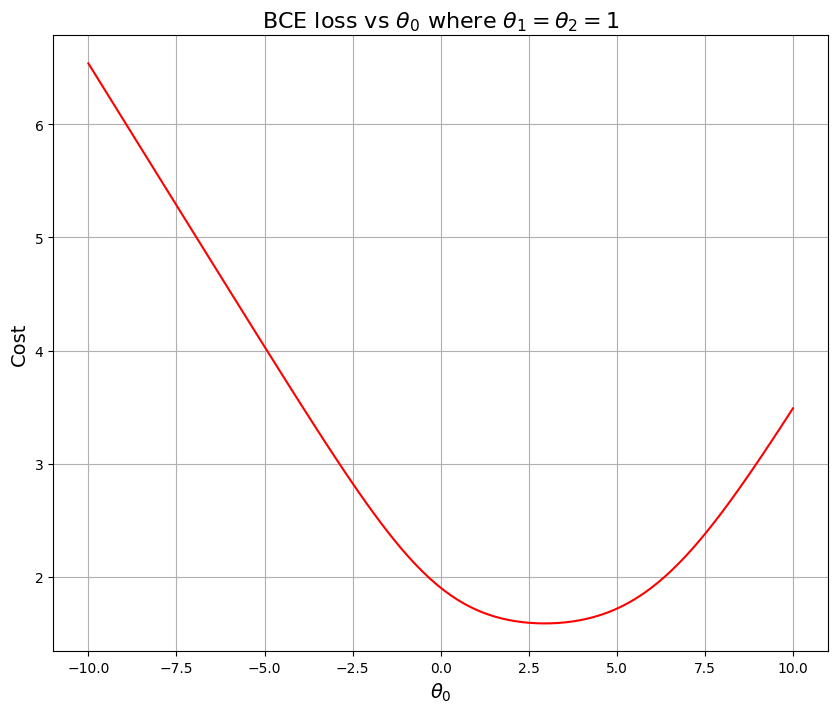

In [27]:
plt.figure(figsize=(10,8))
plt.plot(theta_0_values, bce_costs, 'r-')
plt.title("BCE loss vs $\\theta_0$ where $\\theta_1 = \\theta_2 = 1$", fontsize=16)
plt.xlabel("$\\theta_0$", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.grid()
plt.show()

**Observation**

Using BCE loss we can obtain a convex cost function and that can be minimized using gradient descent optimization.

### Implementation of logistic regression in python from scratch

**Hypostheis function:**

$$ y_p = h_{\theta}(x) = g\left(\theta_0 + \sum_{j=1}^{k}\theta_k x_k \right) $$

Where $g(z) = \frac{1}{1+e^{-z}}$

**Cost function (Binary Cross Entropy loss):**

$$ J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)}log(y^{(i)}_p) + (1-y^{(i)})log(1-y^{(i)}_p)\right)$$

where $m$ = total number of training samples.

**Gradient descent update rule:**

$$ \theta_j(t+1) \leftarrow \theta_j(t) - \alpha \frac{\partial J}{\partial \theta_j}$$

**Now, the partial dervatives are computed as:**

$$ \frac{\partial J}{\partial \theta_0} = \frac{1}{m}\sum_{i=1}^{m} \left(y^{(i)}_p - y^{(i)} \right)\ ;\ \ for\ the\ bias $$
$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m} \left(y^{(i)}_p - y^{(i)} \right)x^{(i)}_j\ ;\ \ for\ the\ other\ weights/parameters $$

In [ ]:
def bce_loss(y_pred, y_actual):
    return (-1)*np.mean(y_actual * np.log(y_pred) + (1-y_actual)*np.log(1-y_pred))

class OurLogisticRegression:

    def __init__(self, learning_rate=0.001, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.bias = None          # theta_0
        self.weights = None       # theta_1, theta_2, theta_3, ... , theta_k
        self.loss = []

    def _sigmoid(self, x):
        return 1/(1+np.exp(-x))
    
    def predict_probability(self, X):
        linear_model = np.dot(X, self.weights) + self.bias     # z = theta_0 + theta_1 * x1 + theta_2 * x2 + .... + theta_k * xk
        predicted_probability = self._sigmoid(linear_model)
        return predicted_probability
    
    def fit(self, X, y):
        n_samples, n_features = X.shape

        # initialize parameters
        self.weights = np.random.rand(n_features)
        self.bias = np.random.rand(1)[0]

        # gradient descent
        for i in range(self.n_iters):

            # predict the probabilty
            y_p = self.predict_probability(X)

            # compute and update the loss
            self.loss.append(bce_loss(y_p, y))

            # compute gradient
            db = (1 / n_samples) * np.sum(y_p - y)         # bias
            dw = (1 / n_samples) * np.dot(X.T, (y_p - y))  # other parameters

            # update parameters
            self.bias -= self.lr * db        # self.bias = self.bias - self.lr * db
            self.weights -= self.lr * dw     # self.weights = self.weights - self.lr * dw

    def predict_class(self, X, threshold = 0.5):
        y_p = self.predict_probability(X)
        y_class = (y_p > threshold).astype('int')   # if probabilty > threshold then 1 else 0
        return y_class

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [ ]:
bc_data = load_breast_cancer()

bc_data['feature_names']

In [ ]:
bc_data

In [ ]:
print(bc_data['DESCR'])

In [ ]:
import pandas as pd

pd.DataFrame(bc_data['data'], columns=bc_data['feature_names'])

In [ ]:
X = bc_data['data'][:,:4]   # first four features
y = bc_data['target']

X.shape, y.shape

In [ ]:
pd.DataFrame(X, columns=bc_data['feature_names'][:4])

In [ ]:
# splitting into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [ ]:
X_train.shape, X_test.shape

In [ ]:
# scaling the features for better performance

sc = StandardScaler()
sc.fit(X_train)
X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

X_train_scaled

In [ ]:
# defining the model

logistic_reg = OurLogisticRegression(learning_rate=0.01, n_iters=1000)

# fitting with the training samples

logistic_reg.fit(X_train_scaled, y_train)

In [ ]:
# plot the loss/cost vs iteration curve

plt.figure(figsize=(10,8))
plt.plot(logistic_reg.loss)
plt.title("Cost vs iterations", fontsize=16)
plt.xlabel("Iterations", fontsize=14)
plt.ylabel("Cost", fontsize=14)
plt.grid()
plt.show()

In [ ]:
# predict the classes of test data

y_test_pred = logistic_reg.predict_class(X_test_scaled)
y_test_pred

In [ ]:
# performance evaluation on test data

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"accuracy = {accuracy:.2f}, precision = {precision:.2f}, recall = {recall:.2f}")

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)  # confusion matrix
cm

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
ConfusionMatrixDisplay(cm).plot()  # displaying the confusion matrix

### Logistic regresion in sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# defining the model

model = LogisticRegression(penalty=None)   # by default the penalty is L2 (ridge). Penalty will be discussed in detail when we talk about regularization.

# fitting with the training sample

model.fit(X_train_scaled, y_train)

In [ ]:
# predict the classes of test data

y_pred_test = model.predict(X_test_scaled)
y_pred_test

In [ ]:
# performance evaluation on test data

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"accuracy = {accuracy:.2f}, precision = {precision:.2f}, recall = {recall:.2f}")

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)   # confusion matrix
cm

In [ ]:
ConfusionMatrixDisplay(cm).plot()  # displaying the confusion matrix